In [6]:
from brainvision.constants import *

## Visualize data

In [7]:
from brainvision.data import load_patient

patient_004_02 = load_patient("../datasets/first_campaign/004-02.zip")
patient_034_01 = load_patient("../datasets/second_campaign/034-01.zip")

/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


In [8]:
import spectral
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


PSEUDO_RGB_BANDS = (29, 20, 11)


def load_jpeg(jpg: str) -> dict:
    """Load the JPEG previews into numpy arrays"""
    return np.array(Image.open(jpg).convert('RGB'), dtype=np.uint8)


def visualise_hypercube(patient: dict, overlay: bool = False, dataKey: str = "reflectance"):
    """Visualise the hypercube alongside the JPEG previews."""
    
    data          = patient[dataKey]
    data_display  = (data - data.min()) / (data.max() - data.min())
    view = spectral.imshow(
        data_display,
        bands=PSEUDO_RGB_BANDS,
        classes=patient['labels'],
        title=f"Patient {patient['id']} — Hypercube",
    )
    if overlay:
        view.set_display_mode('overlay')
        view.class_alpha = 0.5

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Patient {patient['id']} — JPEG Previews")

    patient_image = load_jpeg(patient['image'])
    patient_gt_map = load_jpeg(patient["gt_map"])

    axes[0].imshow(patient_image)
    axes[0].set_title("RGB Preview")
    axes[0].axis('off')

    axes[1].imshow(patient_gt_map)
    axes[1].set_title("Ground Truth Map")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

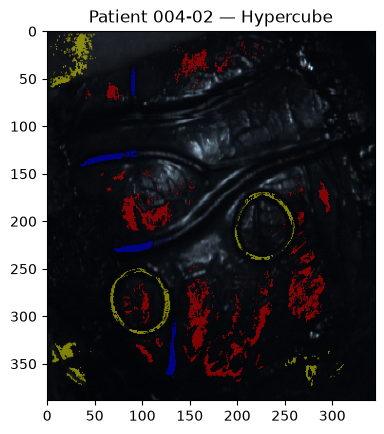

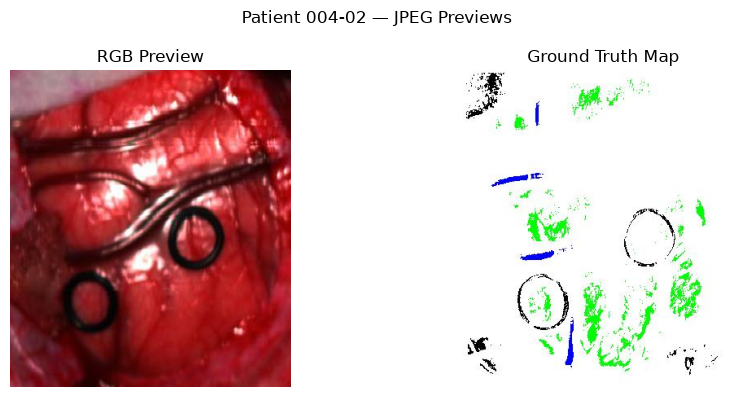

In [9]:
visualise_hypercube(patient_004_02, overlay=True, dataKey="raw")

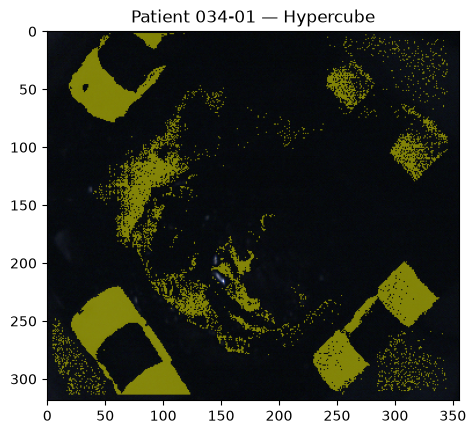

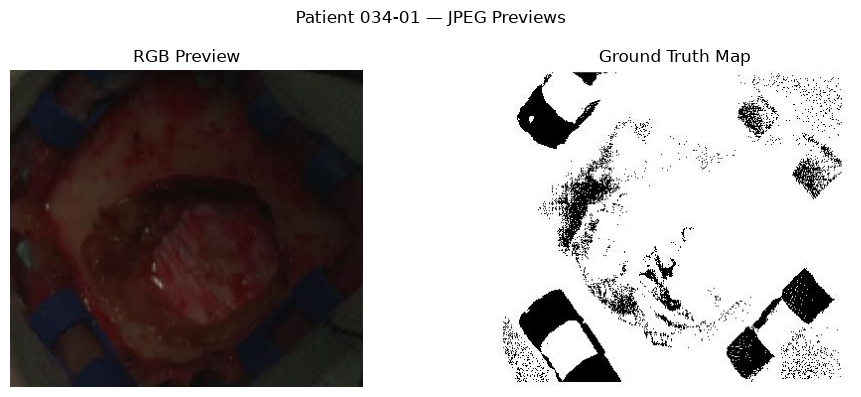

In [31]:
visualise_hypercube(patient_034_01, overlay=True, dataKey="raw")

## Exploratory Data Analysis

In [10]:
import psutil

def check_available_memory():
    free_gb = psutil.virtual_memory().available / 1e9
    total_gb = psutil.virtual_memory().total / 1e9
    print(f"RAM: {free_gb:.1f} GB free of {total_gb:.1f} GB total")
    if free_gb < 2:
        print("⚠️  Less than 2GB free — proceed with caution")

In [17]:
def collect_eda_stats(all_zips: list) -> list[dict]:
    """
    Load each patient one at a time, extract lightweight EDA statistics,
    then discard the raw cube to free memory.

    Returns a list of stat dicts — one per patient — containing only
    the aggregated arrays needed for EDA (no raw cubes retained).
    """
    stats = []
    print(f"Collecting EDA stats for {len(all_zips)} patients...\n")
    print(f"{'ID':<12} {'Shape':<22} {'DN Min':>8} {'DN Max':>8} {'NaN':>6} {'Inf':>6}")
    print("─" * 65)

    for z in all_zips:
        p   = load_patient(str(z))
        raw = p['raw']
        B   = raw.shape[2]

        # Class spectra — only for classes present in this patient
        flat_px     = raw.reshape(-1, B).astype(np.float32)
        flat_labels = p['labels'].reshape(-1)
        class_spectra = {
            c: flat_px[flat_labels == c].mean(axis=0)
            for c in [1, 2, 3, 4]
            if (flat_labels == c).sum() > 0
        }

        # Class pixel counts
        class_counts = {
            c: int((flat_labels == c).sum())
            for c in [0, 1, 2, 3, 4]
        }

        stat = {
            'id':            p['id'],
            'raw_shape':     raw.shape,
            'mean_per_band': flat_px.mean(axis=0),
            'dark_mean':     p['dark'].reshape(-1, p['dark'].shape[2]).mean(axis=0),
            'white_mean':    p['white'].reshape(-1, p['white'].shape[2]).mean(axis=0),
            'labels':        p['labels'],
            'raw_min':       float(raw.min()),
            'raw_max':       float(raw.max()),
            'has_nan':       bool(np.isnan(raw).any()),
            'has_inf':       bool(np.isinf(raw).any()),
            'class_spectra': class_spectra,                  # {class_id: (B,)}
            'class_counts':  class_counts,                   # {class_id: int}
            'image':         p['image'],
            'gt_map':        p['gt_map'],
        }

        stats.append(stat)
        del p, raw, flat_px, flat_labels

        flag = "⚠️" if stat['has_nan'] or stat['has_inf'] else "✅"
        print(f"  {stat['id']:<12} {str(stat['raw_shape']):<22} "
              f"{stat['raw_min']:>8.1f} {stat['raw_max']:>8.1f} "
              f"{str(stat['has_nan']):>6} {str(stat['has_inf']):>6}  {flag}")

    print(f"\n✅ Stats collected for {len(stats)} patients\n")
    return stats

In [18]:
def check_raw_integrity(stats: list[dict]):
    """Flag any patients with NaN, Inf, or unexpected DN ranges."""
    issues = [s for s in stats if s['has_nan'] or s['has_inf']]
    if issues:
        print(f"⚠️  {len(issues)} patients with NaN/Inf: {[s['id'] for s in issues]}")
    else:
        print("✅ No NaN or Inf values across all patients")

In [19]:
def check_label_coverage(stats: list[dict]):
    """Report pixel counts per class per patient. Flag missing classes."""
    print(f"\n{'ID':<12} {'NT':>10} {'TT':>10} {'BV':>10} {'BG':>10}  Status")
    print("─" * 65)
    for s in stats:
        cc     = s['class_counts']
        issues = [CLASS_NAMES[c] for c in [1, 2, 3, 4] if cc.get(c, 0) == 0]
        flag   = f"⚠️  Missing: {issues}" if issues else "✅"
        print(f"  {s['id']:<12} {cc.get(1,0):>10,} {cc.get(2,0):>10,} "
              f"{cc.get(3,0):>10,} {cc.get(4,0):>10,}  {flag}")

In [20]:
def check_spatial_consistency(stats: list[dict]):
    """Check all patients share the same H, W, B dimensions."""
    unique_shapes = set(s['raw_shape'] for s in stats)
    print(f"Unique raw cube shapes: {unique_shapes}")
    if len(unique_shapes) == 1:
        print("✅ All patients have identical dimensions")
    else:
        print("⚠️  Inconsistent shapes:")
        for s in stats:
            print(f"  {s['id']}: {s['raw_shape']}")

In [21]:
def plot_raw_band_profiles(stats: list[dict], n_patients: int = None):
    """
    Plot mean raw DN per band for all/some patients.
    Highlights bands intended for removal.
    """
    n = len(stats) if n_patients is None else n_patients
    fig, ax = plt.subplots(figsize=(12, 5))

    for s in stats[:n]:
        ax.plot(s['mean_per_band'], alpha=0.7, label=s['id'])

    ax.axvspan(0,            BAND_START_IDX, alpha=0.15, color='red',   label=f'Removed (0-{BAND_START_IDX})')
    ax.axvspan(BAND_END_IDX, NUMBER_OF_BANDS,alpha=0.15, color='red',   label=f'Removed ({BAND_END_IDX}-{NUMBER_OF_BANDS})')
    ax.axvspan(BAND_START_IDX, BAND_END_IDX, alpha=0.08, color='green', label=f'Retained ({BAND_START_IDX}-{BAND_END_IDX})')

    ax.set_xlabel("Band index")
    ax.set_ylabel("Mean DN value")
    ax.set_title("Raw DN band profiles — before calibration")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

In [22]:
def plot_reference_profiles(stats: list[dict], n_patients: int = None):
    """
    Plot dark and white reference spectra.
    Dark should be near-zero; white should be high and smooth.
    """
    n = len(stats) if n_patients is None else n_patients
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for s in stats[:n]:
        axes[0].plot(s['dark_mean'],  alpha=0.7, label=s['id'])
        axes[1].plot(s['white_mean'], alpha=0.7, label=s['id'])

    axes[0].set_title("Dark Reference — should be near zero")
    axes[1].set_title("White Reference — should be high & smooth")
    for ax in axes:
        ax.set_xlabel("Band index")
        ax.set_ylabel("Mean DN value")
        ax.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

In [23]:
def plot_raw_class_spectra(stats: list[dict], n_patients: int = None):
    """
    Mean raw DN spectrum per tissue class before any preprocessing.
    Averaged across patients for a robust view of class separability.
    """
    n        = len(stats) if n_patients is None else n_patients
    combined = {c: [] for c in [1, 2, 3, 4]}

    for s in stats[:n]:
        for c, spectrum in s['class_spectra'].items():
            combined[c].append(spectrum)

    fig, ax = plt.subplots(figsize=(11, 5))

    for c in [1, 2, 3, 4]:
        if combined[c]:
            mean = np.stack(combined[c]).mean(axis=0)
            std  = np.stack(combined[c]).std(axis=0)
            ax.plot(mean, color=CLASS_COLORS[c], label=CLASS_NAMES[c])
            ax.fill_between(range(len(mean)),
                            mean - std, mean + std,
                            alpha=0.15, color=CLASS_COLORS[c])

    ax.axvspan(0,            BAND_START_IDX, alpha=0.1, color='red')
    ax.axvspan(BAND_END_IDX, NUMBER_OF_BANDS,alpha=0.1, color='red')
    ax.set_xlabel("Band index (raw)")
    ax.set_ylabel("Mean DN")
    ax.set_title("Raw class spectral signatures — before preprocessing (mean ± std across patients)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [24]:
def plot_class_distribution(stats: list[dict]):
    """
    Global pixel count per class across all patients.
    Reveals class imbalance that loss functions must address.
    """
    totals = {c: sum(s['class_counts'].get(c, 0) for s in stats) for c in [1, 2, 3, 4]}
    total_px  = sum(totals.values())

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(
        [CLASS_NAMES[c] for c in [1, 2, 3, 4]],
        [totals[c] for c in [1, 2, 3, 4]],
        color=[CLASS_COLORS[c] for c in [1, 2, 3, 4]]
    )
    for bar, c in zip(bars, [1, 2, 3, 4]):
        pct = totals[c] / total_px * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.set_ylabel("Total pixel count")
    ax.set_title("Global class distribution — all patients")
    plt.tight_layout()
    plt.show()

    print("\nClass pixel counts:")
    for c in [1, 2, 3, 4]:
        print(f"  {CLASS_NAMES[c]:<25}: {totals[c]:>10,}  ({totals[c]/total_px*100:.1f}%)")

In [25]:
def plot_label_maps(stats: list[dict], n: int = 4):
    """Display GT label map and RGB preview side by side for n patients."""
    from PIL import Image
    from matplotlib.colors import ListedColormap

    cmap   = ListedColormap(['black', '#5DCAA5', '#D85A30', '#378ADD', '#888780'])
    n      = min(n, len(stats))
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))

    for i, s in enumerate(stats[:n]):
        axes[i, 0].imshow(np.array(Image.open(s['image']).convert('RGB')))
        axes[i, 0].set_title(f"{s['id']} — RGB")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(s['labels'], cmap=cmap, vmin=0, vmax=4)
        axes[i, 1].set_title(f"{s['id']} — GT Labels")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [26]:
from brainvision.data import all_campaigns_summary

all_campaigns_summary(CAMPAIGN_DIRS)


── Campaign 1 ────────────────────────────────────────
Campaign : ../datasets/first_campaign
  Images   (n) : 27
  Patients (m) : 16
  Patient IDs  : ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022']
  Image IDs    : ['004-02', '005-01', '007-01', '008-01', '008-02', '010-03', '012-01', '012-02', '013-01', '014-01', '015-01', '016-01', '016-02', '016-03', '016-04', '016-05', '017-01', '018-01', '018-02', '019-01', '020-01', '021-01', '021-02', '021-05', '022-01', '022-02', '022-03']

── Campaign 2 ────────────────────────────────────────
Campaign : ../datasets/second_campaign
  Images   (n) : 24
  Patients (m) : 10
  Patient IDs  : ['034', '035', '036', '037', '038', '039', '040', '041', '042', '043']
  Image IDs    : ['034-01', '034-02', '034-03', '035-01', '035-02', '036-01', '036-02', '037-01', '037-02', '037-03', '037-04', '038-01', '039-01', '039-02', '040-01', '040-02', '041-01', '041-02', '042-01', '042-02', '042-03

In [27]:
from brainvision.data import list_patient_zips

check_available_memory()

campaign_01 = list_patient_zips(data_dir=CAMPAIGN_DIRS[1])

campaign_02 = list_patient_zips(data_dir=CAMPAIGN_DIRS[2])

all_zips = campaign_01
all_zips.extend(campaign_02)

eda_stats = collect_eda_stats(all_zips)

RAM: 6.6 GB free of 25.8 GB total

ID           Shape                    DN Min   DN Max    NaN    Inf
─────────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


  004-02       (389, 345, 826)             7.0   4095.0  False  False  ✅
  005-01       (483, 488, 826)             2.0   4095.0  False  False  ✅
  007-01       (582, 400, 826)             6.0   4095.0  False  False  ✅
  008-01       (460, 549, 826)             2.0   4095.0  False  False  ✅
  008-02       (480, 553, 826)             1.0   4095.0  False  False  ✅
  010-03       (371, 461, 826)             1.0   2560.0  False  False  ✅
  012-01       (443, 497, 826)             4.0   4095.0  False  False  ✅
  012-02       (445, 498, 826)             2.0   4095.0  False  False  ✅
  013-01       (298, 253, 826)             3.0   2807.0  False  False  ✅
  014-01       (317, 244, 826)             2.0   3867.0  False  False  ✅
  015-01       (376, 494, 826)             2.0   4095.0  False  False  ✅
  016-01       (335, 323, 826)             4.0   1542.0  False  False  ✅
  016-02       (335, 326, 826)             3.0   1545.0  False  False  ✅
  016-03       (315, 321, 826)             2.0   25

In [28]:
# Data quality
check_raw_integrity(eda_stats)
check_spatial_consistency(eda_stats)
check_label_coverage(eda_stats)

✅ No NaN or Inf values across all patients
Unique raw cube shapes: {(443, 497, 826), (460, 549, 826), (298, 253, 826), (449, 486, 826), (399, 439, 826), (592, 471, 826), (335, 323, 826), (383, 297, 826), (510, 434, 826), (601, 535, 826), (280, 444, 826), (479, 462, 826), (300, 342, 826), (483, 488, 826), (317, 244, 826), (611, 527, 826), (582, 400, 826), (412, 324, 826), (623, 584, 826), (433, 340, 826), (389, 345, 826), (554, 446, 826), (319, 356, 826), (414, 292, 826), (371, 461, 826), (448, 324, 826), (432, 322, 826), (315, 526, 826), (290, 301, 826), (378, 330, 826), (303, 374, 826), (312, 535, 826), (290, 422, 826), (538, 525, 826), (437, 488, 826), (431, 503, 826), (415, 446, 826), (650, 582, 826), (629, 646, 826), (575, 543, 826), (315, 321, 826), (445, 498, 826), (335, 326, 826), (480, 553, 826), (452, 334, 826), (597, 527, 826), (434, 453, 826), (294, 344, 826), (441, 399, 826), (376, 494, 826), (497, 490, 826)}
⚠️  Inconsistent shapes:
  004-02: (389, 345, 826)
  005-01: (483

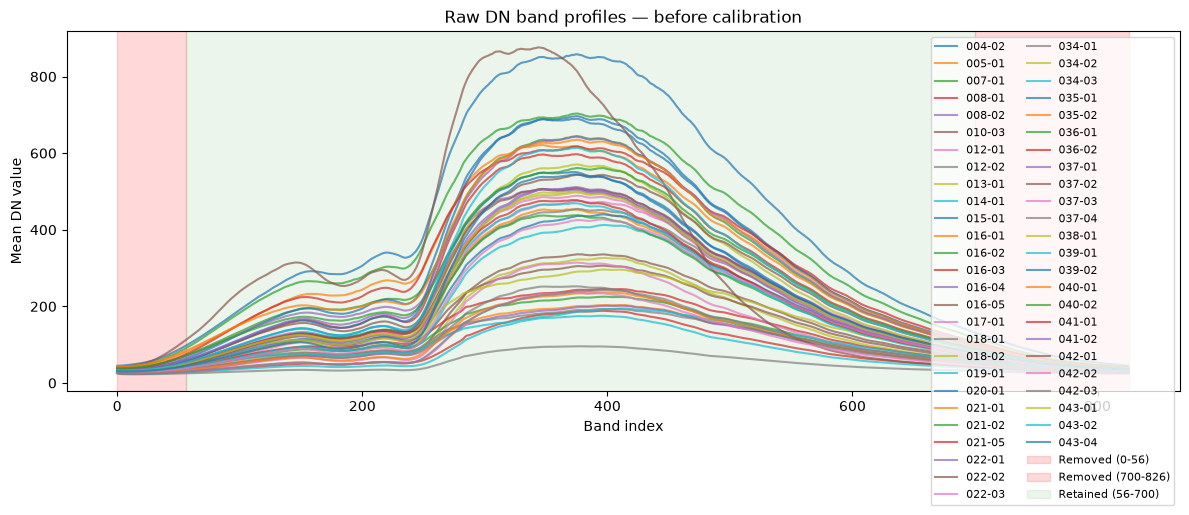

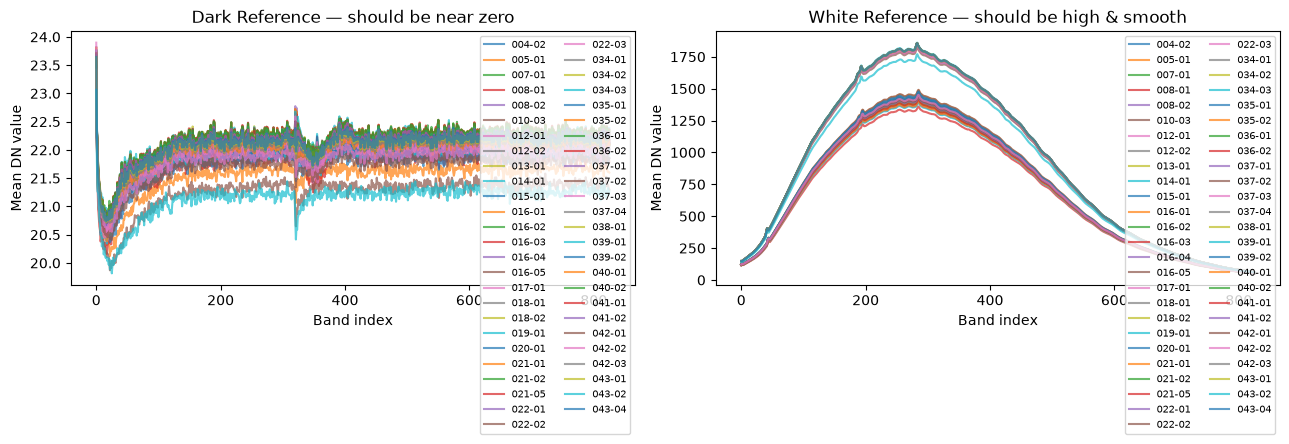

In [29]:
# Sensor behaviour
plot_raw_band_profiles(eda_stats)
plot_reference_profiles(eda_stats)

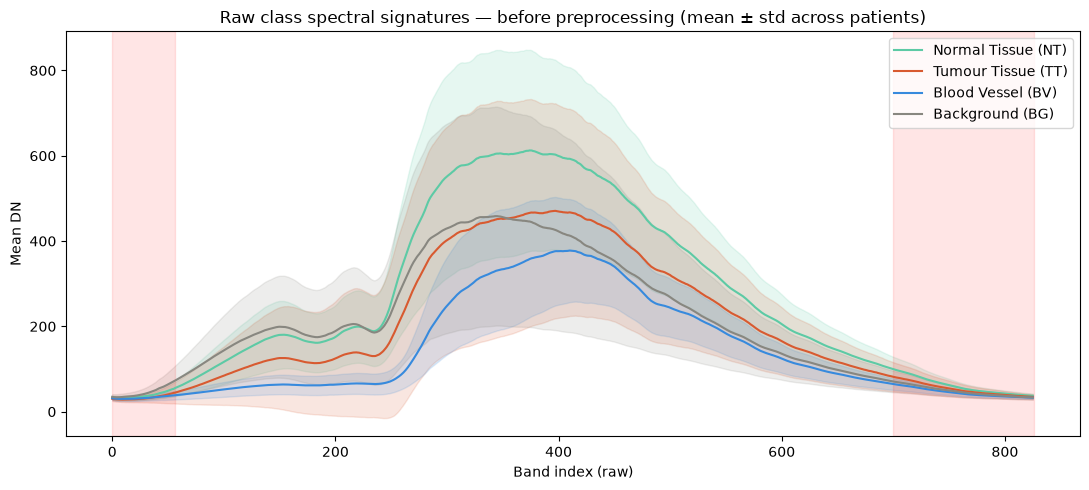

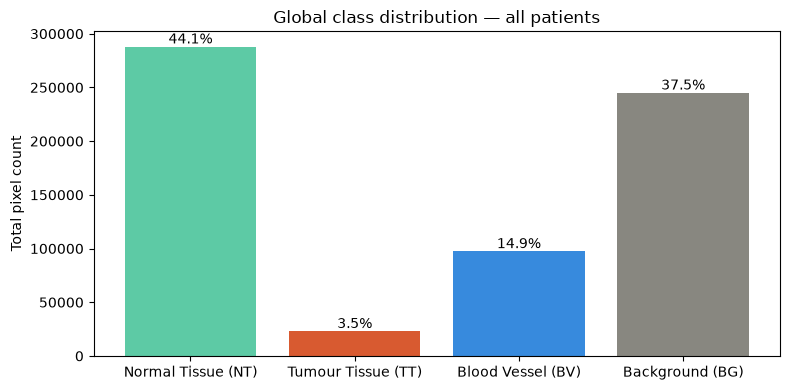


Class pixel counts:
  Normal Tissue (NT)       :    287,828  (44.1%)
  Tumour Tissue (TT)       :     22,860  (3.5%)
  Blood Vessel (BV)        :     97,267  (14.9%)
  Background (BG)          :    244,905  (37.5%)


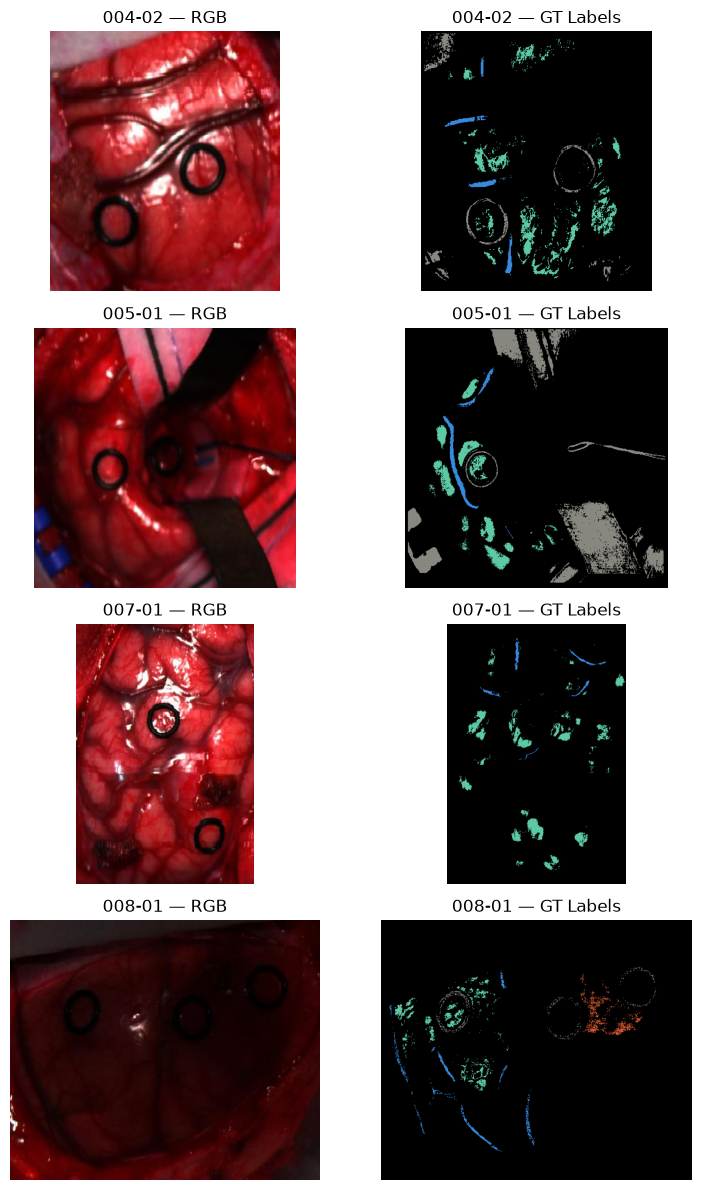

In [30]:
# Class behaviour
plot_raw_class_spectra(eda_stats)
plot_class_distribution(eda_stats)
plot_label_maps(eda_stats, n=4)